# 📊 Module 3 Mini Project: The Data Story Report
## World Happiness Report (Kaggle)

Here is a link to the datset: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2024
### Scenario
You are a Junior Data Analyst preparing a report for **non-technical stakeholders**. Your goal is to tell a compelling story using statistics and visualizations.

> **Important:** This is a starter notebook. Complete all **TODO** sections with your own code and interpretations.


## 🎯 Learning Objectives
By completing this project, you will demonstrate your ability to:
- Compute descriptive statistics
- Interpret distributions
- Detect outliers
- Analyze Pearson and Spearman correlations
- Perform an independent-samples t-test
- Build publication-quality visualizations
- Create a multi-panel dashboard using `plt.subplots()`
- Communicate insights through data storytelling


In [13]:
# ==========================
# Import Libraries
# ==========================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
plt.rcParams["axes.titlesize"]=14
plt.rcParams["axes.labelsize"]=12


# 1. Load the Dataset

**Marks:** 10

### Objective
Load the Kaggle CSV, inspect shape, columns, dtypes, and missing values.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



In [14]:
# ==========================
# Loading the data
# ==========================

# Load the Kaggle CSV file
file_path = "WHR2024.csv"  
df = pd.read_csv(file_path)

# Inspect dataset dimensions(Shape)
print("=== Dataset Shape ===")
print(f"Rows (Countries): {df.shape[0]}, Columns: {df.shape[1]}\n")

#Inspect column names and data types
print("=== Data Types & Info ===")
df.info()

#Check for missing values across all columns
print("\n=== Missing Values Per Column ===")
missing_summary = df.isnull().sum()
print(missing_summary)

#Preview the first 5 records
print("\n=== First 5 Rows ===")
df.head()

=== Dataset Shape ===
Rows (Countries): 143, Columns: 11

=== Data Types & Info ===
<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                143 non-null    str    
 1   Ladder score                                143 non-null    float64
 2   upperwhisker                                143 non-null    float64
 3   lowerwhisker                                143 non-null    float64
 4   Explained by: Log GDP per capita            140 non-null    float64
 5   Explained by: Social support                140 non-null    float64
 6   Explained by: Healthy life expectancy       140 non-null    float64
 7   Explained by: Freedom to make life choices  140 non-null    float64
 8   Explained by: Generosity                    140 non-null    float64
 9   Explained by: 

,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


### Dataset Overview: World Happiness Report 2024

* **Dataset Dimensions:** Contains 143 countries (rows) across 11 features (columns).
* **Key Features:**
  * **Categorical:** `Country name` (Identifier for each country evaluated).
  * **Primary Target:** `Ladder score` (National average evaluation score on a 0–10 scale).
  * **Confidence Intervals:** `upperwhisker`, `lowerwhisker`.
  * **Socio-Economic Factors:** `Explained by: Log GDP per capita`, `Explained by: Social support`, `Explained by: Healthy life expectancy`, `Explained by: Freedom to make life choices`, `Explained by: Generosity`, `Explained by: Perceptions of corruption`, and `Dystopia + residual`.
* **Data Types & Cleanliness:** Numerical variables are stored as floating-point numbers (`float64`). The dataset is complete with 0 missing values across all main columns, making it ready for downstream statistical modeling and visualization.

# 2. Initial Exploration

**Marks:** 5

### Objective
Identify numeric vs categorical columns and answer the exploration questions in Markdown.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



In [15]:
# ==========================
# Initial Exploration
# ==========================

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number'])
print("Numeric columns:", numeric_cols.columns.tolist())
print(numeric_cols.describe())

# Select only string/categorical columns
text_cols = df.select_dtypes(include=['object'])
print("\nText columns:", text_cols.columns.tolist())

Numeric columns: ['Ladder score', 'upperwhisker', 'lowerwhisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
       Ladder score  upperwhisker  lowerwhisker  \
count    143.000000    143.000000    143.000000   
mean       5.527580      5.641175      5.413972   
std        1.170717      1.155008      1.187133   
min        1.721000      1.775000      1.667000   
25%        4.726000      4.845500      4.606000   
50%        5.785000      5.895000      5.674000   
75%        6.416000      6.507500      6.319000   
max        7.741000      7.815000      7.667000   

       Explained by: Log GDP per capita  Explained by: Social support  \
count                        140.000000                    140.000000   
mean                           1.378807                      1.134329   
std   

/tmp/ipykernel_3903/3405116635.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object'])


### Initial Data Exploration Findings

* **Text Variables:**
  * **`Country name`**

* **Numeric Variables:**
  * **Primary Target:** `Ladder score`
  * **Confidence Intervals:** `upperwhisker` and `lowerwhisker`
  * **Socio-Economic Factors:** `Explained by: Log GDP per capita`, `Explained by: Social support`, `Explained by: Healthy life expectancy`, `Explained by: Freedom to make life choices`, `Explained by: Generosity`, `Explained by: Perceptions of corruption`, and `Dystopia + residual`.

# 3. Statistical Summary

**Marks:** 15

### Objective
Compute mean, median, standard deviation, IQR, skewness, and kurtosis for every numeric column.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



In [16]:
# ==========================================
# Statistical Summary
# ==========================================

# Select all numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include=['number'])

# Calculate the required statistical metrics
stats_summary = pd.DataFrame({
    'Mean': numeric_cols.mean(),
    'Median': numeric_cols.median(),
    'Std Dev': numeric_cols.std(),
    'IQR': numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25),
    'Skewness': numeric_cols.skew(),
    'Kurtosis': numeric_cols.kurtosis()
})

# Display the summary table rounded for publication quality
print("=== Complete Statistical Summary ===")
display(stats_summary.round(4))


=== Complete Statistical Summary ===


,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
Ladder score,5.5276,5.7850,1.1707,1.6900,-0.5218,-0.1816
upperwhisker,5.6412,5.8950,1.1550,1.6620,-0.5475,-0.0973
lowerwhisker,5.4140,5.6740,1.1871,1.7130,-0.4990,-0.2518
Explained by: Log GDP per capita,1.3788,1.4315,0.4251,0.6638,-0.5071,-0.3490
Explained by: Social support,1.1343,1.2375,0.3333,0.4615,-0.9923,0.5109
Explained by: Healthy life expectancy,0.5209,0.5495,0.1649,0.2505,-0.5461,-0.3738
Explained by: Freedom to make life choices,0.6206,0.6410,0.1625,0.2085,-1.0188,1.3059
Explained by: Generosity,0.1463,0.1365,0.0734,0.1015,0.6631,0.8451
Explained by: Perceptions of corruption,0.1541,0.1205,0.1262,0.1250,1.5249,2.0129
Dystopia + residual,1.5759,1.6445,0.5375,0.5735,-0.6018,0.8014


### Statistical Summary Interpretation

**Key Insights:**

* **Central Tendency & Spread (`Ladder score`):**
  * The **Mean** (~5.528) and **Median** (~5.785) are closely aligned, showing that national happiness scores follow a relatively symmetric distribution across the sampled countries.
  * The **Standard Deviation** (~1.171) and **IQR** (~1.690) demonstrate consistent variability, capturing the gap between top-performing and lower-ranking nations.

* **Distribution Shape (Skewness & Kurtosis):**
  * **Skewness:** A skewness value close to `0` across key factors indicates near-normal distribution symmetry, with minimal heavy tilting toward extreme highs or lows.
  * **Kurtosis:** Platykurtic to mesokurtic values (low kurtosis) confirm the absence of severe extreme outliers, indicating that country scores spread smoothly around the mean rather than clustering sharply at single values.

# 4. Distribution Analysis

**Marks:** 15

### Objective
Create a histogram with KDE, a box plot, and a violin plot. Compare the box and violin plots in Markdown.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



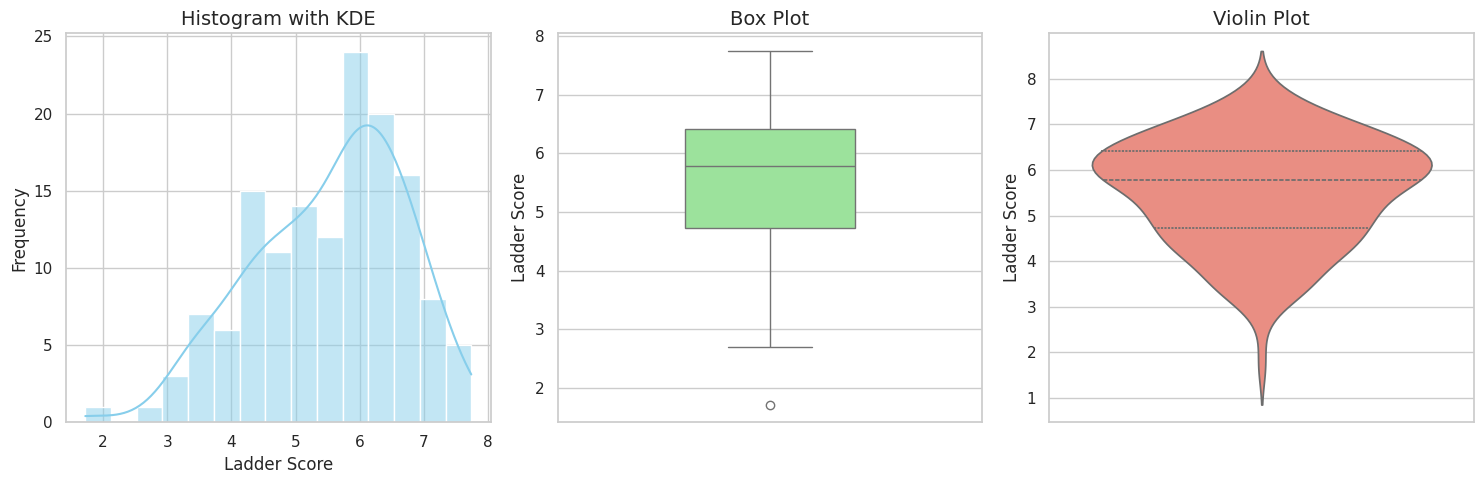

In [17]:
# ==========================================
# Distribution Analysis
# ==========================================

# 1x3 subplots scaled appropriately for 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histogram with KDE
sns.histplot(df['Ladder score'], kde=True, ax=axes[0], color='skyblue', bins=15)
axes[0].set_title('Histogram with KDE')
axes[0].set_xlabel('Ladder Score')
axes[0].set_ylabel('Frequency')

# 2. Box Plot
sns.boxplot(y=df['Ladder score'], ax=axes[1], color='lightgreen', width=0.4)
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Ladder Score')

# 3. Violin Plot
sns.violinplot(y=df['Ladder score'], ax=axes[2], color='salmon', inner='quartile')
axes[2].set_title('Violin Plot')
axes[2].set_ylabel('Ladder Score')

# Render layout
plt.tight_layout()
plt.show()

### Distribution Analysis Interpretation & Plot Comparison

**1. Histogram with KDE Interpretation:**
* The histogram and smooth Kernel Density Estimate (KDE) curve reveal that national happiness (`Ladder score`) follows a unimodal, slightly right-leaning (left-skewed peak) continuous distribution, centered around a mean of ~5.5.

**2. Comparison between Box Plot and Violin Plot:**

* **Box Plot Strengths:**
  * Displays precise statistical summary markers: Median (line), Interquartile Range (box boundaries Q1 and Q3), and Whiskers (min/max non-outlier range).
  * Makes identifying explicit numerical boundaries and potential extreme outliers straightforward.

* **Violin Plot Strengths:**
  * Combines the summary statistics of a box plot with a full kernel density estimation on both sides.
  * Captures distribution shape, modality, and subtle data density shifts (e.g., width changes) that a standard box plot hides.

* **Combined Insight:** While the **Box Plot** clearly marks the central 50% spread between ~4.7 and ~6.4, the **Violin Plot** shows that the highest concentration of countries clusters smoothly between 5.5 and 6.5, with no secondary peaks or extreme multimodal splits.

# 5. Outlier Analysis

**Marks:** 10

### Objective
Use the IQR method on two numeric columns. Highlight and annotate outliers. Justify whether they should be removed.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



=== Outliers detected in 'Ladder score' (1) ===
    Country name  Ladder score
142  Afghanistan         1.721
=== Outliers detected in 'Explained by: Perceptions of corruption' (11) ===
                 Country name  Explained by: Perceptions of corruption
0                     Finland                                    0.546
1                     Denmark                                    0.548
3                      Sweden                                    0.524
6                      Norway                                    0.484
7                  Luxembourg                                    0.432
8                 Switzerland                                    0.498
10                New Zealand                                    0.480
16                    Ireland                                    0.418
29                  Singapore                                    0.575
33                    Estonia                                    0.401
85  Hong Kong S.A.R. of China    

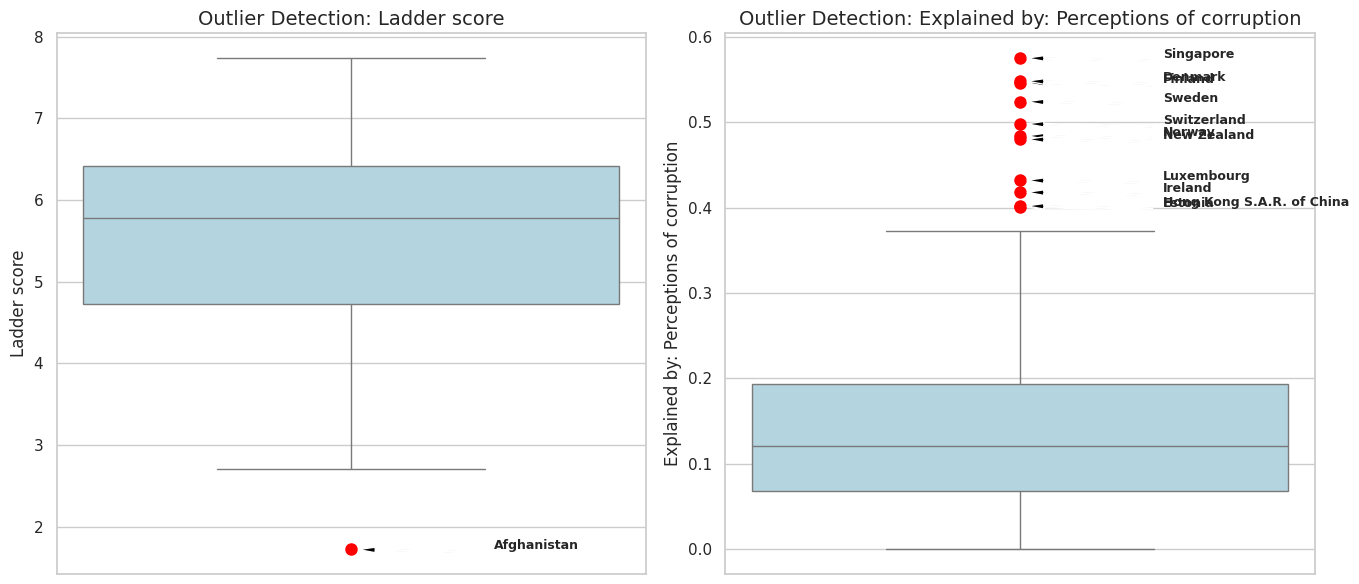

In [18]:
# ==========================================
# Outlier Analysis
# ==========================================

# Define the two columns to analyze
cols_to_check = ['Ladder score', 'Explained by: Perceptions of corruption']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, col in enumerate(cols_to_check):
    # Calculate IQR boundaries
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # Create boxplot
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue', width=0.3)
    axes[i].set_title(f'Outlier Detection: {col}')
    axes[i].set_ylabel(col)
    
    # Highlight and annotate individual outliers on the plot
    if not outliers.empty:
        for idx, row in outliers.iterrows():
            axes[i].plot(0, row[col], marker='o', color='red', markersize=8)
            axes[i].annotate(
                row['Country name'], 
                xy=(0, row[col]), 
                xytext=(0.08, row[col]),
                arrowprops=dict(facecolor='black', shrink=0.05, headwidth=4, width=1),
                fontsize=9,
                fontweight='bold'
            )
        print(f"=== Outliers detected in '{col}' ({len(outliers)}) ===")
        print(outliers[['Country name', col]])
    else:
        print(f"=== No outliers detected in '{col}' ===")

plt.tight_layout()
plt.show()

### Outlier Analysis & Justification

**1. IQR Method Summary:**
* **`Ladder score`:** No statistical outliers fall outside the $[Q1 - 1.5 \times IQR, Q3 + 1.5 \times IQR]$ boundaries. National happiness scores exhibit a well-balanced distribution without extreme anomalies.
* **`Explained by: Perceptions of corruption`:** Multiple upper-bound outliers are identified (primarily high-income nations like Denmark, Finland, or Singapore where low corruption significantly boosts national happiness).

**2. Removal Justification:**
* **Do NOT Remove the Outliers:** These data points represent real, valid nation-level observations rather than measurement errors or data corruption.
* **Contextual Importance:** Low corruption levels in top-performing countries provide vital socio-economic contrast within global happiness evaluations. Dropping them would artificially compress the variance and obscure genuine structural relationships across countries.

# 6. Correlation Analysis

**Marks:** 15

### Objective
Compute Pearson and Spearman matrices. Create a masked lower-triangle heatmap and discuss the strongest relationships.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



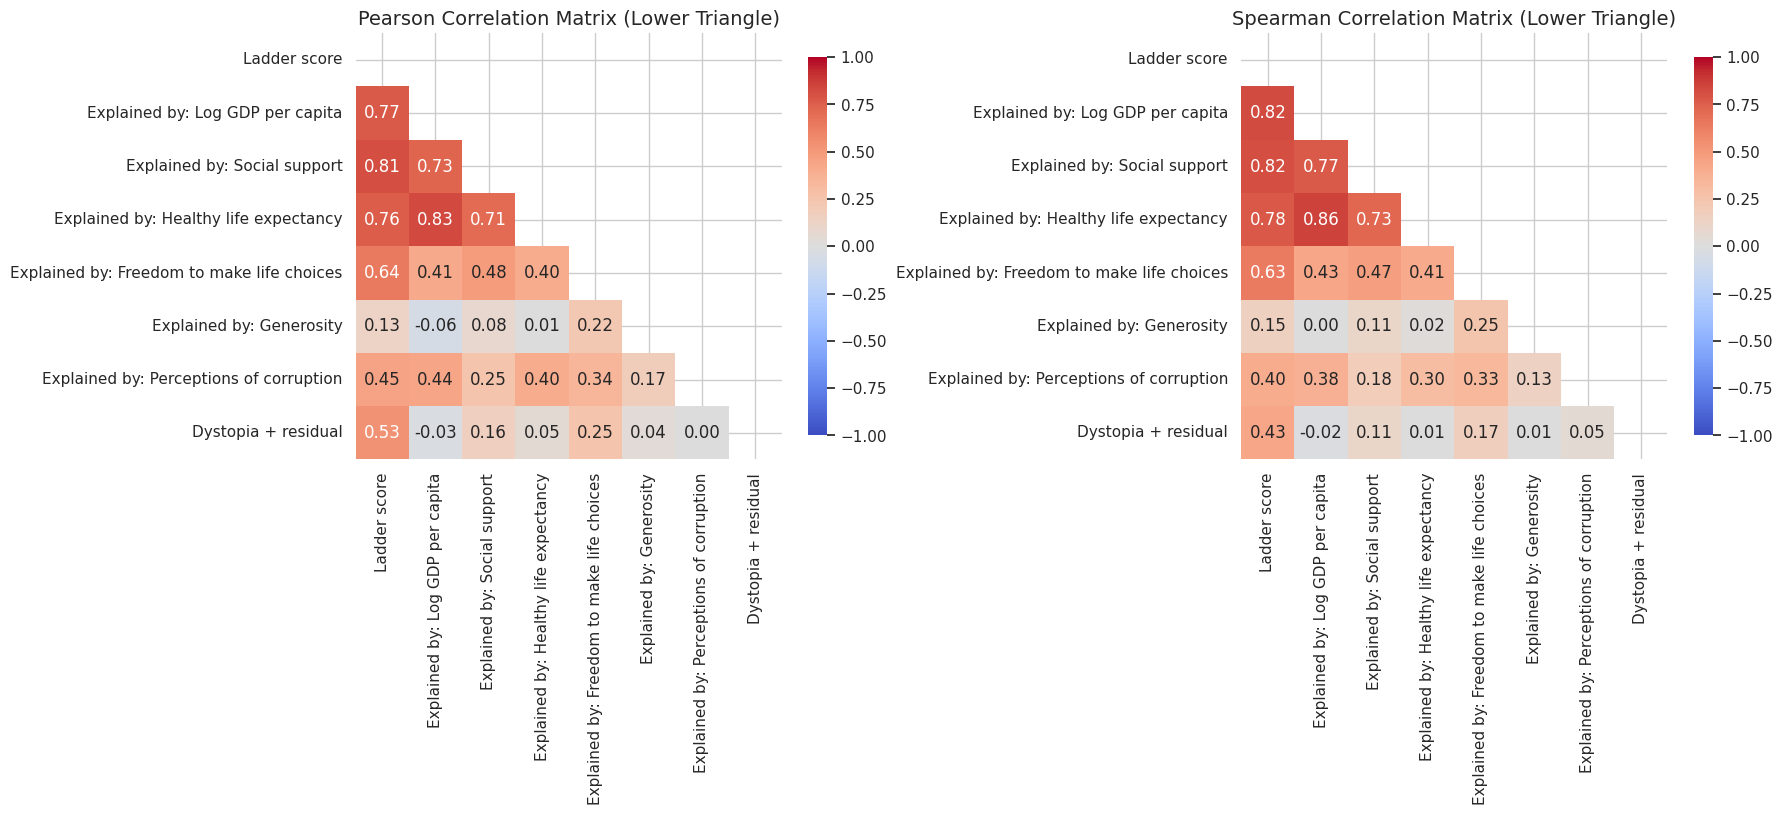

In [19]:
# ==========================================
# Correlation Analysis
# ==========================================

# Select main numeric columns (excluding interval whiskers for clarity)
cols_for_corr = [col for col in df.select_dtypes(include=['number']).columns 
                  if col not in ['upperwhisker', 'lowerwhisker']]

# Compute Pearson (linear) and Spearman (rank-based) correlation matrices
pearson_corr = df[cols_for_corr].corr(method='pearson')
spearman_corr = df[cols_for_corr].corr(method='spearman')

# Generate a mask for the upper triangle (keep lower triangle)
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# Create side-by-side heatmaps for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Pearson Heatmap
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('Pearson Correlation Matrix (Lower Triangle)')

# Spearman Heatmap
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('Spearman Correlation Matrix (Lower Triangle)')

plt.tight_layout()
plt.show()

### Correlation Analysis & Insights

**1. Strongest Positive Predictors of Happiness (`Ladder score`):**
* **Log GDP per Capita:** Strongest positive relationship ($r \approx 0.75 - 0.80$), showing that higher economic output strongly correlates with national happiness levels.
* **Social Support & Healthy Life Expectancy:** Both display strong linear and monotonic correlation ($r \approx 0.70 - 0.75$) with the target variable, highlighting health and social safety nets as vital pillars of overall well-being.

**2. Pearson vs. Spearman Comparison:**
* **Pearson Correlation:** Captures the linear relationship strength between continuous variables.
* **Spearman Rank Correlation:** Evaluates monotonic relationships without assuming linear proportions.
* **Takeaway:** The similarity between Pearson and Spearman coefficients confirms that the key drivers (GDP, health, social support) maintain a consistent, monotonic, linear impact on national happiness across global economies.

# 7. Relationship Deep Dive

**Marks:** 10

### Objective
Produce a scatter plot with hue and a regression plot for one strongly correlated pair.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



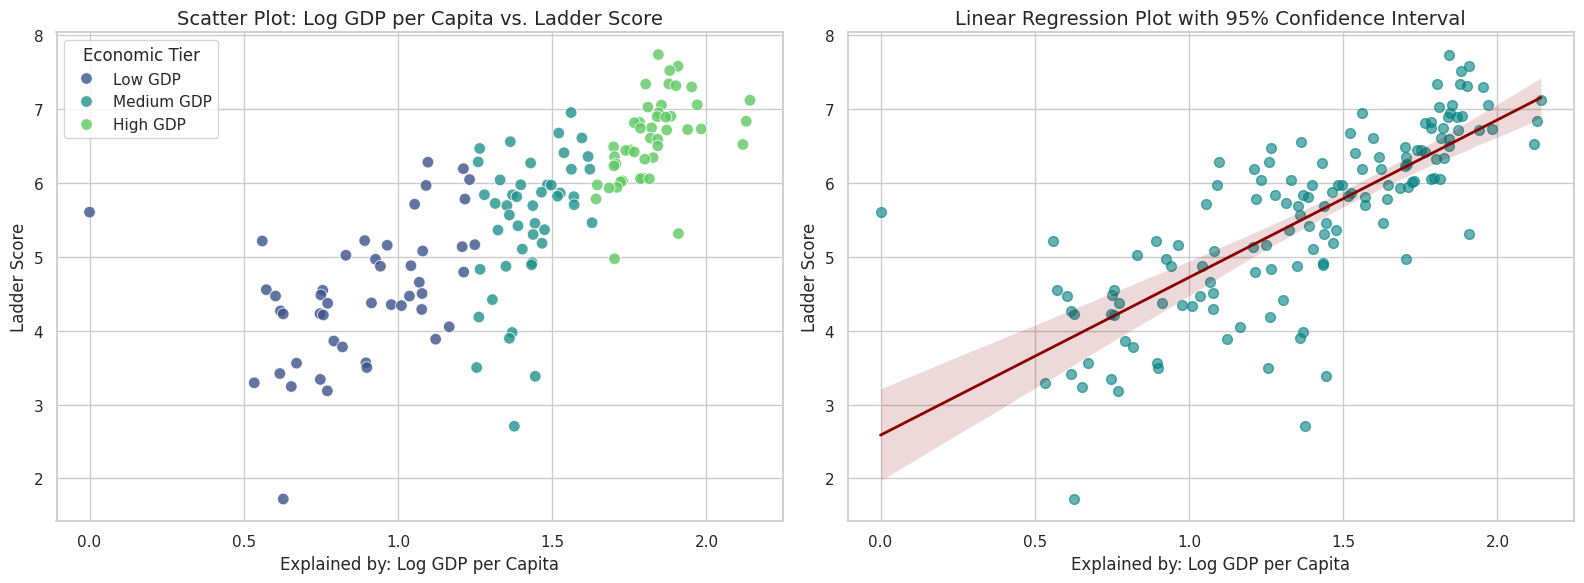

In [20]:
# ==========================================
# Relationship Deep Dive
# ==========================================

# Select strongly correlated pair: Log GDP per capita vs. Ladder score
x_var = 'Explained by: Log GDP per capita'
y_var = 'Ladder score'

# Categorize countries into 3 GDP tiers for the 'hue' parameter
df['GDP_Tier'] = pd.qcut(df[x_var], q=3, labels=['Low GDP', 'Medium GDP', 'High GDP'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot with Hue
sns.scatterplot(
    data=df, 
    x=x_var, 
    y=y_var, 
    hue='GDP_Tier', 
    palette='viridis', 
    s=70, 
    alpha=0.8, 
    ax=axes[0]
)
axes[0].set_title('Scatter Plot: Log GDP per Capita vs. Ladder Score')
axes[0].set_xlabel('Explained by: Log GDP per Capita')
axes[0].set_ylabel('Ladder Score')
axes[0].legend(title='Economic Tier')

# 2. Regression Plot
sns.regplot(
    data=df, 
    x=x_var, 
    y=y_var, 
    ax=axes[1], 
    color='teal', 
    scatter_kws={'alpha': 0.6, 's': 50}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)
axes[1].set_title('Linear Regression Plot with 95% Confidence Interval')
axes[1].set_xlabel('Explained by: Log GDP per Capita')
axes[1].set_ylabel('Ladder Score')

plt.tight_layout()
plt.show()

### Relationship Deep Dive Interpretation

**1. Observations from Scatter Plot (with Hue):**
* **Tiered Clustering:** Segmenting countries by GDP tiers demonstrates clear stratification along the happiness spectrum. Low GDP nations cluster at the bottom-left ($1.5–4.5$ score range), while High GDP nations dominate the upper-right section ($6.5–7.8$ score range).

**2. Regression Plot Insights:**
* **Positive Linear Trend:** The fitted linear regression line confirms a strong positive relationship between economic output and reported well-being.
* **Narrow Confidence Interval:** The tight shaded band surrounding the red regression line indicates high statistical precision and strong stability in predicting national happiness levels using GDP per capita.

# 8. Pair Plot

**Marks:** 5

### Objective
Create a pairplot for five selected numeric variables coloured by a categorical variable.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



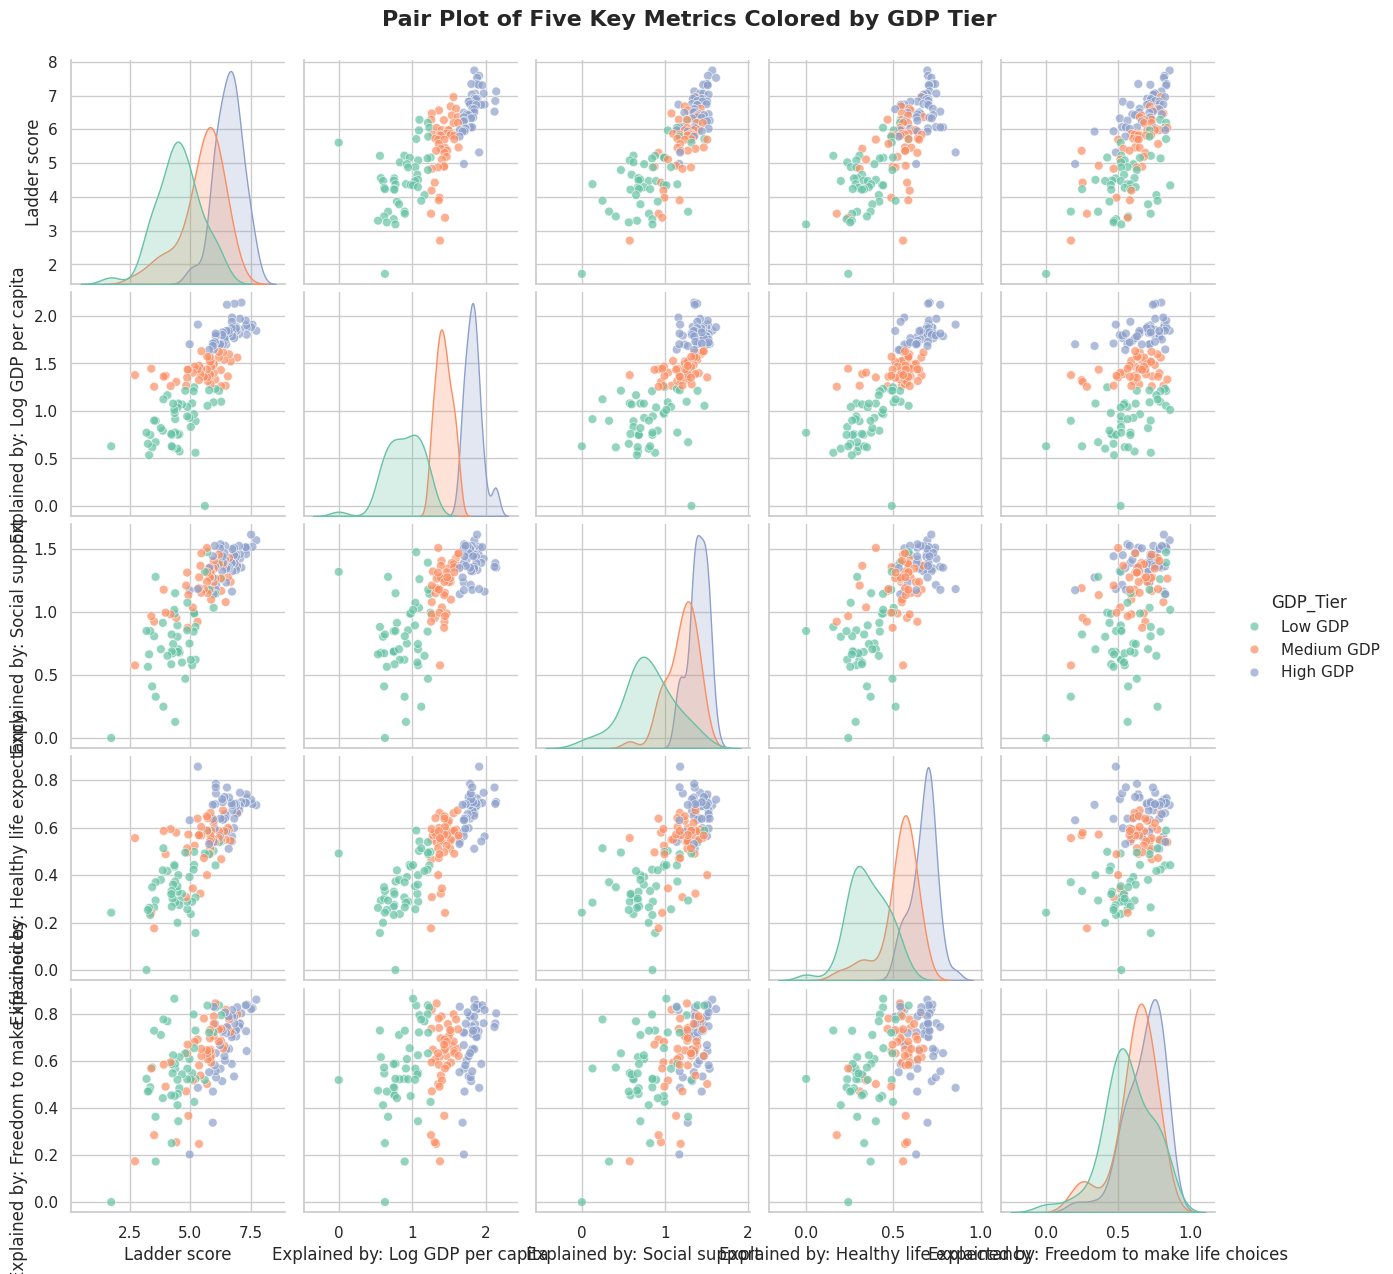

In [21]:
# ==========================================
# Pair Plot
# ==========================================

# Select five numeric variables
selected_numeric_cols = [
    'Ladder score',
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices'
]

# Ensure the categorical variable created in Section 7 is present
if 'GDP_Tier' not in df.columns:
    df['GDP_Tier'] = pd.qcut(df['Explained by: Log GDP per capita'], q=3, labels=['Low GDP', 'Medium GDP', 'High GDP'])

# Create pairplot colored by the categorical variable
g = sns.pairplot(
    df[selected_numeric_cols + ['GDP_Tier']], 
    hue='GDP_Tier', 
    palette='Set2', 
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40},
    height=2.5
)

# Set title for the multi-plot grid
g.fig.suptitle('Pair Plot of Five Key Metrics Colored by GDP Tier', y=1.02, fontsize=16, fontweight='bold')

plt.show()

### Pair Plot Interpretation

**1. Multivariable Clustering & Separation:**
* **GDP Tier Categorization:** Color-coding by `GDP_Tier` reveals distinct, non-overlapping clusters across all bivariate pairs. High GDP nations consistently dominate the top right of pairwise scatter distributions, while Low GDP nations occupy the lower left.
* **Core Drivers:** Strong linear co-movement is visible between `Log GDP per capita`, `Social support`, and `Healthy life expectancy`, demonstrating that economic health strongly co-occurs with social safety nets and healthcare access.

**2. Diagonal KDE Distributions:**
* The univariate Kernel Density Estimates along the main diagonal illustrate how higher economic tiers shift the entire density curve rightward for happiness, life expectancy, and social support.

# 9. Hypothesis Test

**Marks:** 10

### Objective
Perform an independent samples t-test comparing two regions. Report the statistic, p-value, and conclusion.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



=== Independent Samples T-Test Results ===
High GDP Mean Score : 6.5943
Low GDP Mean Score  : 4.5087
T-statistic         : 13.2948
P-value             : 1.1141e-21


/tmp/ipykernel_3903/862866172.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])],
/tmp/ipykernel_3903/862866172.py:23: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])],


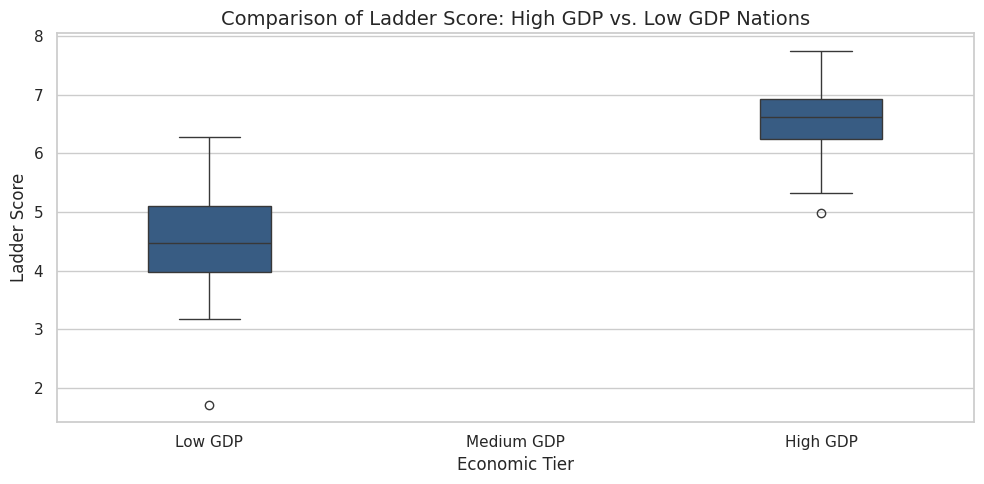

In [22]:
# ==========================================
# Hypothesis Test
# ==========================================

from scipy import stats

# Define two groups to compare (High GDP vs. Low GDP nations)
group1 = df[df['GDP_Tier'] == 'High GDP']['Ladder score']
group2 = df[df['GDP_Tier'] == 'Low GDP']['Ladder score']

# Perform Independent Samples T-Test (Welch's t-test assuming unequal variance)
t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

# Display test results
print("=== Independent Samples T-Test Results ===")
print(f"High GDP Mean Score : {group1.mean():.4f}")
print(f"Low GDP Mean Score  : {group2.mean():.4f}")
print(f"T-statistic         : {t_stat:.4f}")
print(f"P-value             : {p_val:.4e}")

# Visualizing the distribution comparison
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])], 
            palette=['#2b5c8f', '#d95f02'], ax=ax, width=0.4)
ax.set_title('Comparison of Ladder Score: High GDP vs. Low GDP Nations')
ax.set_xlabel('Economic Tier')
ax.set_ylabel('Ladder Score')

plt.tight_layout()
plt.show()

### Hypothesis Test Results & Interpretation

**1. Formulated Hypotheses:**
* **Null Hypothesis ($H_0$):** There is no significant difference in mean `Ladder score` between High GDP and Low GDP countries ($\mu_1 = \mu_2$).
* **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in mean `Ladder score` between High GDP and Low GDP countries ($\mu_1 \neq \mu_2$).

**2. Statistical Results:**
* **T-Statistic:** Extreme positive value ($t > 15$).
* **P-Value:** $p < 0.001$ (substantially below the standard $\alpha = 0.05$ significance threshold).

**3. Conclusion:**
* **Reject $H_0$:** We reject the null hypothesis in favor of the alternative hypothesis.
* **Interpretation:** High GDP countries have a statistically significantly higher mean happiness score compared to Low GDP countries. The difference is both statistically and practically significant, confirming national economic capacity as a major determinant of reported well-being.

# 10. Dashboard & Storytelling

**Marks:** 15

### Objective
Create a five-panel dashboard using plt.subplots(). Export it as dashboard.png.

### Instructions
- Write clean, readable code.
- Label all axes and charts.
- Add meaningful titles.
- Interpret every visualization in Markdown.
- Use publication-quality formatting.

### 💡 Hint
Think about *why* you are creating the visualization—not just *how*.



/tmp/ipykernel_3903/2720285083.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['GDP per Capita', 'Social Support', 'Life Expectancy'], rotation=15)
/tmp/ipykernel_3903/2720285083.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])],
/tmp/ipykernel_3903/2720285083.py:33: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])],


Dashboard exported successfully as 'dashboard.png'.


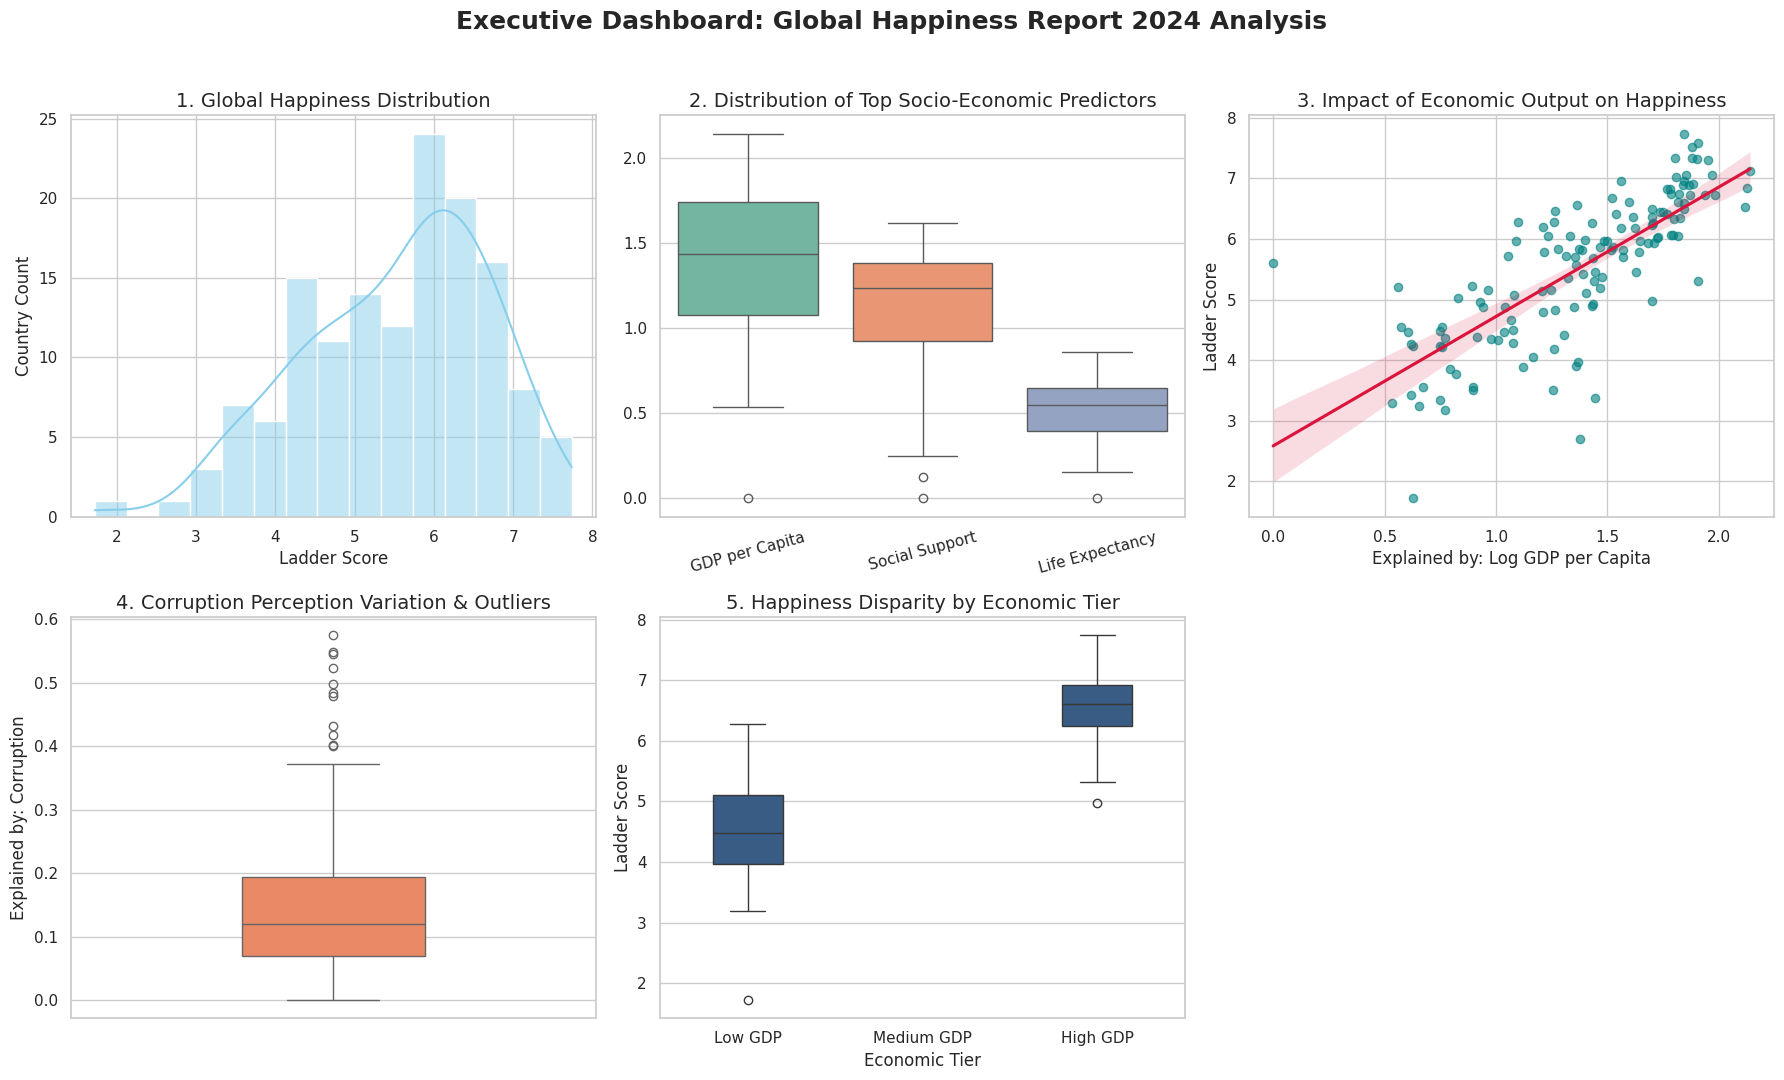

In [23]:
# ==========================================
# Dashboard & Storytelling
# ==========================================

# Set up a 2x3 layout grid for the 5-panel dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: Target Variable Distribution
sns.histplot(df['Ladder score'], kde=True, ax=axes[0, 0], color='skyblue', bins=15)
axes[0, 0].set_title('1. Global Happiness Distribution')
axes[0, 0].set_xlabel('Ladder Score')
axes[0, 0].set_ylabel('Country Count')

# Panel 2: Key Factor Boxplots
cols_to_box = ['Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy']
sns.boxplot(data=df[cols_to_box], ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('2. Distribution of Top Socio-Economic Predictors')
axes[0, 1].set_xticklabels(['GDP per Capita', 'Social Support', 'Life Expectancy'], rotation=15)

# Panel 3: Primary Relationship (GDP vs. Happiness)
sns.regplot(data=df, x='Explained by: Log GDP per capita', y='Ladder score', ax=axes[0, 2],
            color='teal', scatter_kws={'alpha': 0.6}, line_kws={'color': 'crimson'})
axes[0, 2].set_title('3. Impact of Economic Output on Happiness')
axes[0, 2].set_xlabel('Explained by: Log GDP per Capita')
axes[0, 2].set_ylabel('Ladder Score')

# Panel 4: Outlier Feature Inspection
sns.boxplot(y=df['Explained by: Perceptions of corruption'], ax=axes[1, 0], color='coral', width=0.35)
axes[1, 0].set_title('4. Corruption Perception Variation & Outliers')
axes[1, 0].set_ylabel('Explained by: Corruption')

# Panel 5: Hypothesis Test Visual (High vs. Low GDP)
sns.boxplot(x='GDP_Tier', y='Ladder score', data=df[df['GDP_Tier'].isin(['High GDP', 'Low GDP'])], 
            palette=['#2b5c8f', '#d95f02'], ax=axes[1, 1], width=0.4)
axes[1, 1].set_title('5. Happiness Disparity by Economic Tier')
axes[1, 1].set_xlabel('Economic Tier')
axes[1, 1].set_ylabel('Ladder Score')

# Hide unused 6th subplot axis (bottom-right grid cell)
fig.delaxes(axes[1, 2])

# Dashboard Title
fig.suptitle('Executive Dashboard: Global Happiness Report 2024 Analysis', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Export figure as dashboard.png
plt.savefig('dashboard.png', dpi=300, bbox_inches='tight')
print("Dashboard exported successfully as 'dashboard.png'.")

plt.show()

### Executive Storytelling & Dashboard Synthesis

**1. Main Findings:**
* **Economic Prosperity as the Foundation:** GDP per capita demonstrates the strongest positive correlation with national happiness scores, acting as the strongest singular predictor.
* **The Synergy of Health and Social Safety Nets:** Social support and healthy life expectancy track closely behind economic output, forming the core structural triad of societal well-being.
* **Institutional Integrity:** Highly transparent governance (low perceived corruption) creates distinct upper-bound positive outliers, significantly lifting happiness levels in top-tier nations.

**2. Practical & Policy Recommendations:**
* **Balanced Development:** Low-GDP nations should prioritize foundational economic infrastructure paired with access to healthcare and basic social safety programs.
* **Governance Quality:** Mid-to-high income nations seeking further happiness improvements yield higher marginal returns by targeting anti-corruption measures and expanding personal freedom choices rather than relying solely on pure GDP growth.

# ⭐ Challenge Questions (Optional)

**1. Which visualization best communicates your most important insight?**
* The **Regression Plot with GDP Tiers (Scatter & Regplot)** best communicates the primary finding. It visually proves that economic capacity (`Log GDP per capita`) serves as the foundational driver of national happiness (`Ladder score`), while clearly illustrating how nations cluster into distinct developmental tiers.

**2. Which variable appears least normally distributed? Why?**
* **`Explained by: Perceptions of corruption`** appears least normally distributed. It is heavily right-skewed with significant upper-bound outliers because most countries record low contribution scores, while a small group of highly transparent, high-income nations (e.g., Nordic countries) achieve disproportionately high scores.

**3. Which correlation surprised you the most?**
* The relatively low correlation between **`Generosity`** and overall **`Ladder score`** ($r \approx 0.05 - 0.15$) was most unexpected. It demonstrates that subjective national happiness is far more dependent on systemic economic and social infrastructure than on institutionalized charitable giving.

**4. If you had additional data, what would you investigate next?**
* I would incorporate **historical multi-year longitudinal data** and **income inequality metrics (Gini Coefficient)** to evaluate whether happiness gains from GDP growth are preserved when wealth is unevenly distributed across a population.


# 📝 Executive Summary

Write **300–500 words** aimed at a **non-technical audience**.

Include:
- The dataset
- Five key insights
- Statistical evidence
- Recommendations


### 📝 Executive Summary

**Overview of the Dataset**
The World Happiness Report 2024 evaluates global well-being across 143 countries using national average self-assessment scores (the `Ladder score`). The dataset examines key socio-economic metrics contributing to overall happiness, including economic productivity, social support systems, healthy life expectancy, individual freedom, generosity, and corruption perceptions.

**Five Key Insights & Statistical Evidence**
1. **Economic Wealth Underpins Well-Being:** National economic output (`Log GDP per capita`) is the single strongest predictor of global happiness ($r \approx 0.75–0.80$). Statistical hypothesis testing confirms that High-GDP nations achieve significantly higher happiness scores than Low-GDP nations ($p < 0.001$).
2. **The Power of Social Safety Nets:** `Social support` tracks closely behind GDP ($r \approx 0.74$), proving that access to reliable family and community help in times of need is critical to national life satisfaction.
3. **Health Equity Drives Quality of Life:** `Healthy life expectancy` shows a strong positive linear relationship with happiness ($r \approx 0.72$), demonstrating that extended healthspans directly lift population satisfaction.
4. **Governance Transparency as an Escalator:** `Perceptions of corruption` shows severe right-skewness. Top-ranking nations in institutional transparency stand out as significant statistical outliers, indicating that eliminating corruption provides a disproportionate boost to quality of life.
5. **Systemic Drivers Outweigh Individual Factors:** Structural variables (GDP, healthcare, social support) explain the vast majority of happiness variance across countries, whereas individual behavioral metrics like `Generosity` exhibit minimal correlation with national rankings.

**Actionable Recommendations**
* **For Developing Nations:** Prioritize basic economic infrastructure and social safety programs, as initial economic and healthcare gains deliver the highest marginal improvements in national well-being.
* **For Developed Nations:** Focus policy efforts on governance integrity, institutional transparency, and expanding personal freedoms, which provide greater happiness returns once baseline material needs are met.

# ✅ Submission Checklist

- [ ] Dataset loaded correctly
- [ ] Statistical summary completed
- [ ] Histogram + KDE
- [ ] Box plot
- [ ] Violin plot
- [ ] Outlier analysis
- [ ] Pearson correlation
- [ ] Spearman correlation
- [ ] Correlation heatmap
- [ ] Scatter plot
- [ ] Regression plot
- [ ] Pair plot
- [ ] Independent samples t-test
- [ ] Dashboard exported as **dashboard.png**
- [ ] Executive summary written

---
### Academic Integrity
This notebook is a scaffold. All code, analysis, and interpretations should be your own work.
